In [1]:
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

import numpy as np
import os
import scipy
import pickle
import random

from neurolib.models.aln import ALNModel
from neurolib.models.rate_control import RateModel
import neurolib.utils.functions as func
from neurolib.utils import costFunctions as cost
from neurolib.utils import plotFunctions as plotFunc

plt.rcParams['image.cmap'] = 'plasma'
cpalette = sns.color_palette('plasma')
np.set_printoptions(precision=6)

font = {
    'family' : 'sans',
    'weight' : 'normal',
    'size'   : 14
       }

matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=16) 
matplotlib.rc('ytick', labelsize=16) 
matplotlib.rc('grid', c='0.5', ls='-', lw=0.5)  # solid gray grid lines
matplotlib.rc('savefig', dpi=300)       # higher res outputs
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 

path = os.getcwd()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
def step_control(maxI_ = 1.):
    control_ = aln.getZeroControl()
    for i_time in range(control_.shape[2]):
        if ( float(i_time/control_.shape[2]) < 0.1):
            control_[:,:2,i_time] = - maxI_
        elif ( float(i_time/control_.shape[2]) > 0.5 and float(i_time/control_.shape[2]) < 0.6 ):
            control_[:,:2,i_time] = maxI_
    return control_

In [3]:
def setinitvars(vars):
    for iv in range(len(init_vars)):
        for sv in range(len(state_vars)):
            if state_vars[sv] in init_vars[iv]:
                if aln.params[init_vars[iv]].ndim == 2:
                    aln.params[init_vars[iv]][0,:] = vars[sv]
                else:
                    aln.params[init_vars[iv]][:] = vars[sv]
                    

In [4]:
tol = 1e-32

c_scheme = np.zeros(( 1,1 ))
c_scheme[0,0] = 1.
u_mat = np.identity(1)
u_scheme = np.array([[1.]])

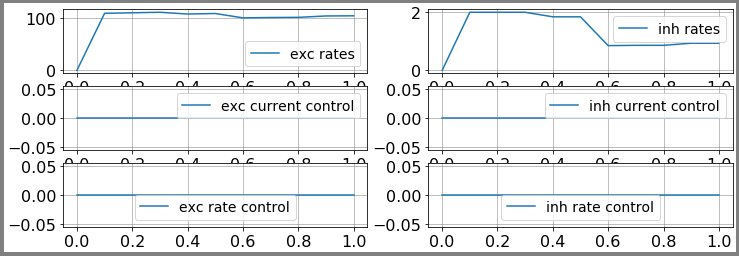

In [54]:
aln = RateModel()

aln.params['duration'] = 1.
aln.params.dt = 0.1
control0 = aln.getZeroControl()

# NO ADAPTATION
aln.params.IA_init = np.array([0.])
aln.params.a = 0.
aln.params.b = 0.

# no noise
aln.params.sigma_ou = 0.
aln.params.mue_ext_mean = 0.
aln.params.mui_ext_mean = 0.
aln.params.sigmae_ext = 0.
aln.params.sigmai_ext = 0.
aln.params.ext_exc_current = 0.
aln.params.ext_inh_current = 0.

# no delay
aln.params.signalV = 0.
aln.params.de = 0.4
aln.params.di = 0.2

aln.params.cie = 1.
aln.params.Jie_max = 1.
aln.params.tau_se = 1.
aln.params.tau_si = 1.
aln.params.C = 1.
aln.params.gL = 1.
aln.params.Ke = 1000.
aln.params.Ki = 1000.

plotFunc.plot_traces(aln, control0)

output = aln.output_vars

state_vars = aln.state_vars
init_vars = aln.init_vars

high_state_vars = np.zeros(( len(state_vars) ))
for i in range(len(state_vars)):
    if aln.state[state_vars[i]].size == 1:
        high_state_vars[i] = aln.state[state_vars[i]][0]
    else:
        high_state_vars[i] = aln.state[state_vars[i]][0,-2]

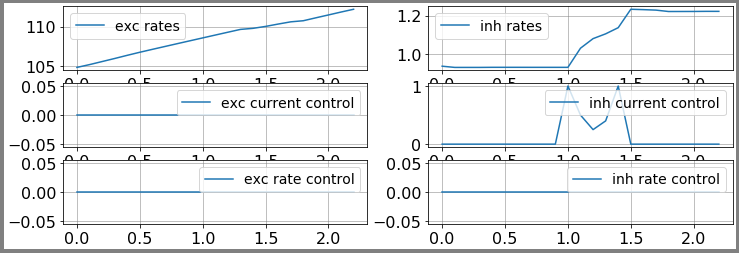

delay : 
sigma e  [[105.20973166 105.59460941 105.97948717 106.37820739 106.76308514
  107.1290356  107.49044864 107.8513252  108.20982594 108.56761652
  108.92493404 109.28103588 109.63567994 109.76943894 110.01195209
  110.30785991 110.58680371 110.72549651 111.09353804 111.45339894
  111.81828572 112.16733405  32.34479748]]


In [55]:
dur = 1.6
dur_pre = 0.6
dur_post = 0.6

n_dur = int(np.around(dur/aln.params.dt + 1.,1))
n_pre = int(np.around(dur_pre/aln.params.dt + 1.,1))
n_post = int(np.around(dur_post/aln.params.dt + 1.,1))

aln.params.duration = dur + dur_pre

control_ind = [1]
prec_var = [0]

if control_ind[0] == 0 or control_ind[0] == 1:
    max_cntrl = 5.
    min_cntrl = -0.
else:
    max_cntrl = 15.#0.5
    min_cntrl = -5.#0.5

control0 = aln.getZeroControl()
#control0[0,control_ind,:] =  np.sin(np.arange(0,dur+1, 1))
#control0[0,control_ind,0] = 1.
for j in control_ind:
    #control0[0,j,n_pre + 0] = 1.0 * max_cntrl - 0.0 * min_cntrl
    #control0[0,j,n_pre + 1] = 0.4 * max_cntrl - 0.2 * min_cntrl
    control0[0,j,n_pre + 3] = 0.2 * max_cntrl - 0.2 * min_cntrl
    control0[0,j,n_pre + 4] = 0.1 * max_cntrl #- 0.2 * min_cntrl
    control0[0,j,n_pre + 5] = 0.05 * max_cntrl #- 0.4 * min_cntrl
    control0[0,j,n_pre + 6] = 0.08 * max_cntrl #- 0.6 * min_cntrl
    control0[0,j,n_pre + 7] = 0.2 * max_cntrl - 0.8 * min_cntrl

setinitvars(high_state_vars)
aln.params.de = 0.4
aln.params.di = 0.2
plotFunc.plot_traces(aln, control0)
print("delay : ")
#print("exc rates : ", aln.rates_exc[0,:])
#print("inh rates : ", aln.rates_inh[0,:])
print("sigma e ", aln.state["sigmae_f"])

aln.params.duration = dur
target = aln.getZeroTarget()
target[0,0,:] = aln.rates_exc[0,n_pre-1:]
target[0,1,:] = aln.rates_inh[0,n_pre-1:]

control1 = aln.getZeroControl()
for k in range(1, control1.shape[2]-2):
    control1[0,j,k] += random.uniform(0., 1.) * 0.1 * max_cntrl

In [60]:
costparams = [1. * 1e0, 1.* 1e-3, 1.* 1e-3]
cost.setParams(costparams[0], costparams[1], costparams[2])

setinitvars(high_state_vars)
max_it = 1000
start_step = 10.
alg = "A1"
case = "test"

aln.params.duration = dur
    
#control1 = aln.getZeroControl()
control2 = bestControlA[:,:,n_pre-1:-n_pre+1]
#control3 = bestControlA_A2[:,:,n_pre-1:-n_pre+1]
control3 = control0[:,:,n_pre-1:]
#control3[0,control_ind[0],3:6] -= 0.001
#control2[:,:,-2:] = 0.

cvar = [None, "HS", "FR", "PR", "HZ"]
cgv = cvar[0]

bestControlA, bestStateA, costA, runtimeA, grad = aln.A1(control2, target, c_scheme, u_mat, u_scheme,
        max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl, 
        min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post,
        CGVar = cgv, control_variables_ = control_ind, prec_variables_ = prec_var)

for j in control_ind:
    print("control ind ", j )
    print("grad = ", grad[0,j,:])
    print("best control = ", bestControlA[0,j,:])

for i in range(1, len(costA)):
    if costA[i-1] < costA[i]:
        print("ERROR ---------------- in index ", i)
        
print("total runtime = ", runtimeA[-1])
# 0.0023455659049372796
# 0.002345565904937199

set cost params
RUN  0 , total integrated cost =  0.0005989855997991133
RUN  1 , total integrated cost =  0.0005989855997974496
RUN  2 , total integrated cost =  0.0005989855997971512
RUN  3 , total integrated cost =  0.0005989855997966908
RUN  4 , total integrated cost =  0.0005989855997961758
RUN  5 , total integrated cost =  0.0005989855997957466
RUN  6 , total integrated cost =  0.0005989855997956141
RUN  7 , total integrated cost =  0.0005989855997954692
RUN  8 , total integrated cost =  0.0005989855997953369
RUN  9 , total integrated cost =  0.000598985599795217
RUN  10 , total integrated cost =  0.0005989855997950252
RUN  11 , total integrated cost =  0.0005989855997947757
RUN  12 , total integrated cost =  0.0005989855997946432
RUN  13 , total integrated cost =  0.0005989855997944795
RUN  14 , total integrated cost =  0.0005989855997943135
RUN  15 , total integrated cost =  0.0005989855997940684
RUN  16 , total integrated cost =  0.0005989855997939661
RUN  17 , total integrated

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  70 , total integrated cost =  0.0005989855997830833
RUN  80 , total integrated cost =  0.0005989855997823633
RUN  90 , total integrated cost =  0.0005989855997816783
Control only changes marginally.
Improved over  90  iterations by  2.9107525278959656e-09  percent.
Problem in initial value trasfer:  sigmae_f 16.362323733862347 107.49044864007084
Problem in initial value trasfer:  sigmae_f 32.34476596664927 112.52572876312249
control ind  1
grad =  [0.00000000e+00 5.89960172e-05 8.46839326e-09 8.38343182e-09
 8.12542301e-09 7.71320822e-09 7.16330668e-09 6.47029516e-09
 5.67214344e-09 4.68952315e-09 3.62075028e-09 8.83176591e-05
 1.20591383e-09 1.23574384e-08 1.79248338e-08 0.00000000e+00
 0.00000000e+00]
best control =  [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00 -0.00000000e+00
  4.15932225e-03  4.86838633e-02  9.22272093e-01  5.06012942e-01
  2.81899677e-01  4.17896547e-01  9.14482003e-01  5.01595021e-02
  3.27

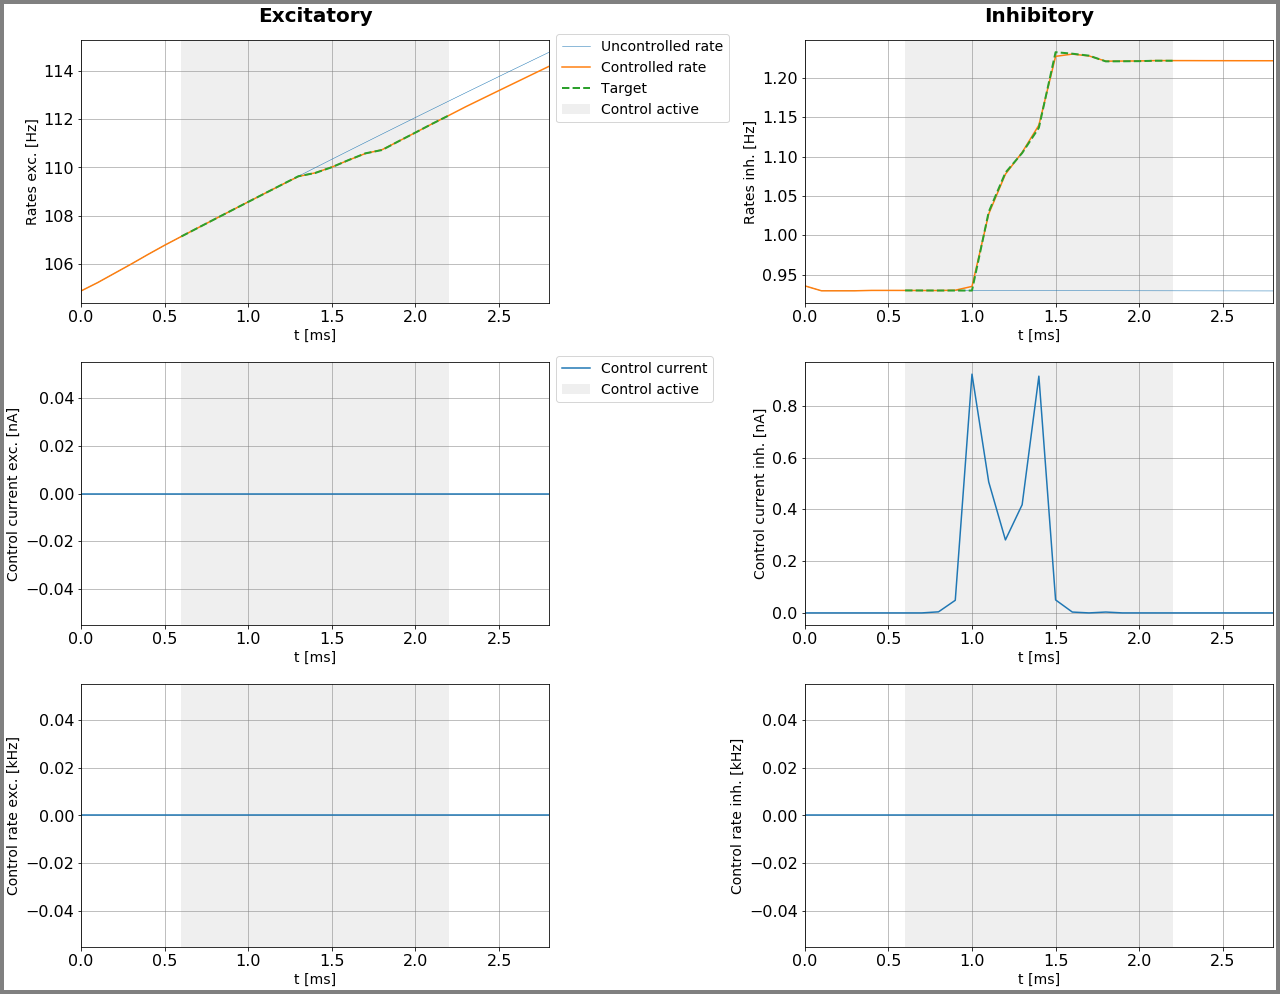

In [59]:
plotFunc.plot_control(aln, bestControlA, dur, dur_pre, dur_post, high_state_vars, target, path)

In [13]:
cost.setParams(costparams[0], costparams[1], costparams[2])
setinitvars(high_state_vars)
max_it = 10
start_step = 1.
alg = "A2"
case = "test"
incl_step = 10
test_step = 1e-6

aln.params.duration = dur
control3 = aln.getZeroControl()
#control4 = bestControlA_A2[:,:,n_pre-1:-n_pre+1]

bestControlA_A2, bestStateA_A2, costA_A2, runtimeA_A2 = aln.A2(control3, target,
        max_iteration_ = max_it,  tolerance_ = tol, include_timestep_ = incl_step,
        start_step_ = start_step, test_step_ = test_step, max_control_ = max_cntrl,
        min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre,
        t_sim_post_ = dur_post, control_variables_ = control_ind, prec_variables_ = prec_var)

for i in range(1, len(costA_A2)):
    if costA_A2[i-1] < costA_A2[i]:
        print("ERROR ---------------- in index ", i)
        
print(bestControlA_A2[0,control_ind[0],:])

ERROR:root:not implemented for less than full timesteps


set cost params
RUN  0 , total integrated cost:  1.52172922427358e-06
step size =  (0.0027343750000000007, 1.5181630380699585e-06, 1.0)
step size =  (0.0025390625000000005, 1.514993011892795e-06, 1.0)
step size =  (0.0025390625000000005, 1.5081373229182975e-06, 1.0)
step size =  (0.0025390625000000005, 1.5015760172518325e-06, 1.0)
step size =  (0.0027343750000000007, 1.4946137584624035e-06, 1.0)
step size =  (0.0027343750000000007, 1.4878925793517527e-06, 1.0)
step size =  (0.0025390625000000005, 1.4811325207216447e-06, 1.0)
step size =  (0.0021484375, 1.4752363366667792e-06, 1.0)
step size =  (0.0015625, 1.470760579700846e-06, 1.0)
step size =  (0.00107421875, 1.4678471035246141e-06, 1.0)
step size =  (0.0006835937500000002, 1.40918638014515e-06, 1.0)
step size =  (0.00031738281250000007, 1.2782608448313386e-06, 1.0)
RUN  1 , total integrated cost:  1.4940372547481836e-06
step size =  (0.0001220703125, 1.4940295788199937e-06, 1.0)
step size =  (6.7138671875e-05, 1.4940272616425439e-06

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


step size =  (8.58306884765625e-07, 1.4775634024437873e-06, 1.0)
RUN  3 , total integrated cost:  1.4940110368309391e-06
Control only changes marginally.
RUN  4 , total integrated cost:  1.4940110368309391e-06
Improved over  4  iterations by  1.8214927465740658  percent.
Problem in initial value trasfer:  sigmae_f 16.97495133312364 21.428406239316462
Problem in initial value trasfer:  sigmae_f 66.5765562590169 48.2655356828843
[0.       0.       0.       0.       0.       0.       0.       0.002612
 0.002472 0.002462 0.002556 0.002713 0.002631 0.002448 0.002069 0.00157
 0.001077 0.000674 0.000307 0.       0.       0.       0.       0.
 0.       0.       0.       0.       0.      ]


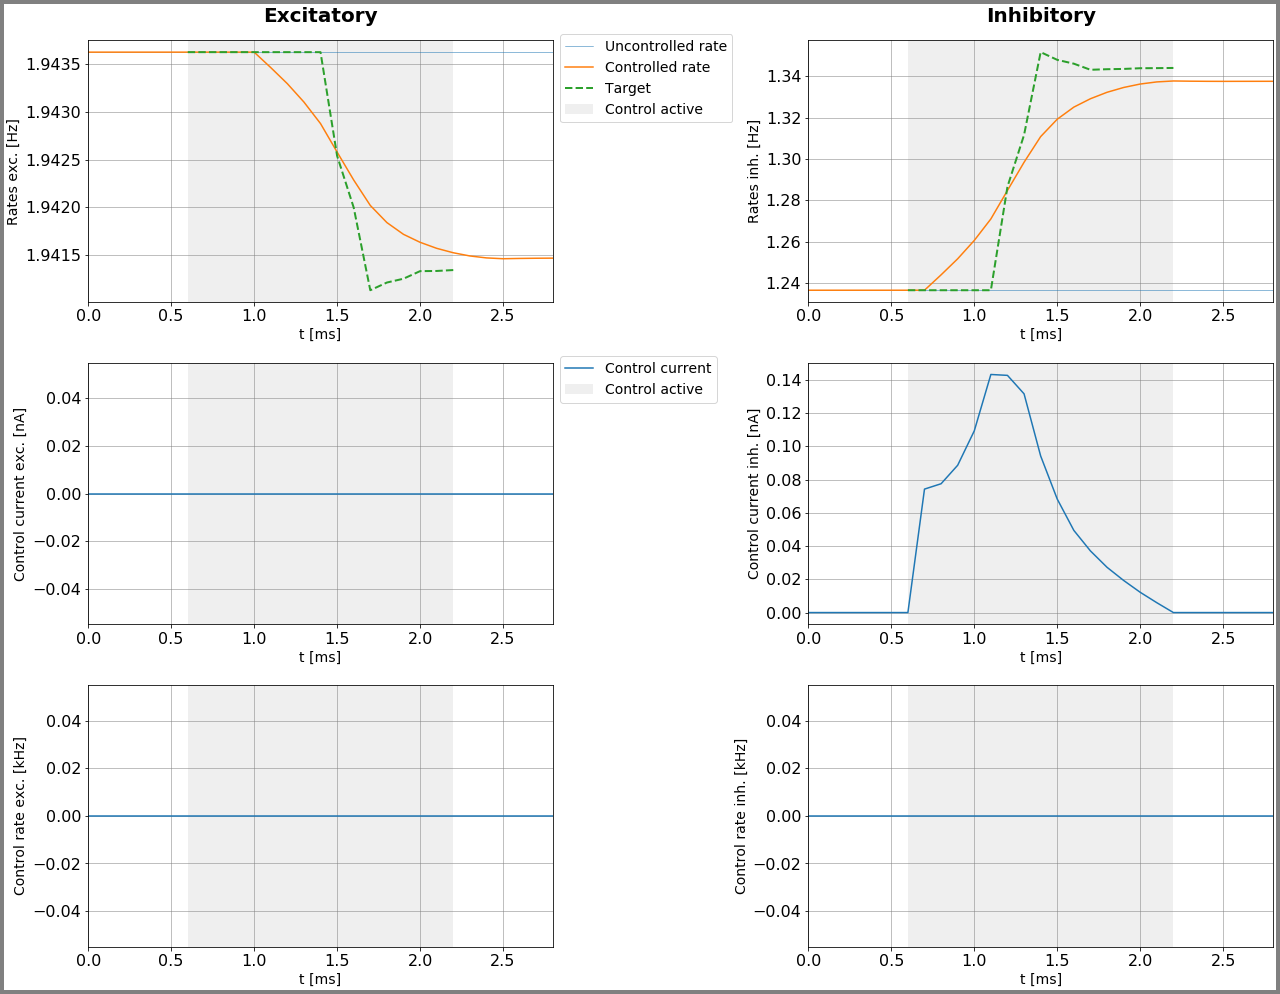

In [1511]:
plotFunc.plot_control(aln, bestControlA_A2, dur, dur_pre, dur_post, high_state_vars, target, path)

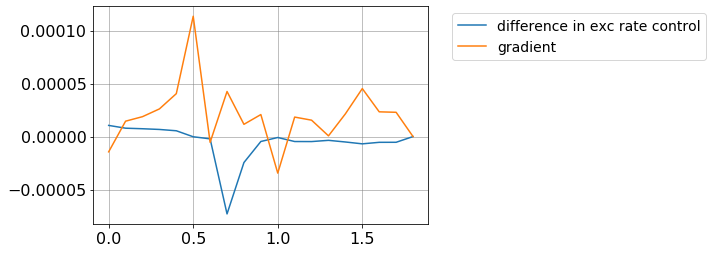

In [1219]:
diff = bestControlA_A2 - bestControlA
#diff[0,2,-2:] = 0.

#c_diff = costA_A2[6] - costA[3]
#print(c_diff)

t = np.arange(0,dur+0.1, 0.1)

#plt.plot(t, diff[0,0,:], label="difference in exc current control")
#plt.plot(t, diff[0,1,:], label="difference in inh current control")
#plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
#plt.grid()
#plt.show()

plt.plot(t, diff[0,2,n_pre-1:-n_post+1], label="difference in exc rate control")
#plt.plot(t, diff[0,3,n_pre:-n_post], label="difference in inh rate control")
plt.plot(t, grad[0,2,:], label="gradient")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.show()

### Testcases

1. PRECISION ONLY, NO DELAY
    - [x] 0 control, 0 precision measure, no delay
    - [x] 1 control, 1 precision measure, no delay
    - [x] 0 control, 1 precision measure, no delay
    - [x] 1 control, 0 precision measure, no delay
    - [] 2 control, 0 precision measure, no delay (slow to converge)
    - [] 2 control, 1 precision measure, no delay (slow to converge)

2. PRECISON + ENERGY + SPARSITY, NO DELAY
    - [x] 0 control, 0 precision measure, no delay
    - [x] 1 control, 1 precision measure, no delay
    - [] 0 control, 1 precision measure, no delay (requires different weights, gradient vanishes, A2 performes differently and worse)
    - [] 1 control, 0 precision measure, no delay (requires different weights, gradient vanishes, A2 performes differently and worse)
    - [x] 2 control, 0 precision measure, no delay
    - [] 2 control, 1 precision measure, no delay (requires different weights, zero control as output, gradient nonvanishing because on boundary. At higher weights, gradient vanishes)
    
3. PRECISION ONLY, DELAY
    - [x] 0 control, 0 precision measure, delay
    - [x] 1 control, 1 precision measure, delay
    - [] 0 control, 1 precision measure, delay (not in every case, could have several solutions)
    - [] 1 control, 0 precision measure, delay (not in every case, could have several solutions)
    - [x] 2 control, 0 precision measure, delay (sometimes slow convergence)
    - [x] 2 control, 1 precision measure, delay (sometimes slow to converge)

4. PRECISON + ENERGY + SPARSITY
    - [] 0 control, 0 precision measure, delay (gradient does not quite vanish)
    - [] 1 control, 1 precision measure, delay (gradient does not quite vanish)
    - [] 0 control, 1 precision measure, delay (requires different weights, gradient does not quite vanish, A2 performes differently and worse)
    - [] 1 control, 0 precision measure, delay (requires different weights, gradient does not quite vanish, A2 performes differently and worse)
    - [] 2 control, 0 precision measure, delay (gradient does not quite vanish)
    - [] 2 control, 1 precision measure, delay (requires different weights, gradient does not quite vanish, A2 performes differently and worse)
    
The cost functional should always have more than one minimum. If the "direct" control (0,0; 1,1; 2,0; 3,1) is not applied, it is much more likely to end up in a local minimum, because there is no "dominant" contribution.

### What to take into account and don't forget
- if delay is present, always leave sufficient time steps before and after applying control
- allowing rates smaller than zero may cause trouble, because then same input can have different effect at different points of time
- is the fact that control enters computation at various points causing problems?
- if stuff of different orders of magnitude is competing, convergence is slow
- convergence in integration variables is much slower than in direct input
- make sure variables are in proper range: setting e.g. sigma to zero in time integration can cause problems